In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams.update({
    "text.usetex": False,               # disable if no full TeX install
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

In [3]:
# Load Sharon's annotated data
results_df = pd.read_csv("../results/model_results_all_chapters_1649.csv")
sharon_data = pd.read_excel("../data/manual/pride_and_prejudice.xlsx", sheet_name="ALL INSTANCES")

In [4]:
results_df.head(50)

,chapter,method,character,tag,count
0,1,whole,Captain Carter,N,0
1,1,whole,Captain Carter,A,0
2,1,whole,Captain Carter,C,0
3,1,whole,Captain Carter,I,0
4,1,whole,Captain Carter,DN,0
5,1,whole,Captain Carter,DC,0
6,1,whole,Charlotte Lucas,N,0
7,1,whole,Charlotte Lucas,A,0
8,1,whole,Charlotte Lucas,C,0
9,1,whole,Charlotte Lucas,I,0


In [5]:
sharon_data["chapter"] = pd.to_numeric(sharon_data["Graph Chapter"], errors="coerce").astype("Int64")
sharon_data = sharon_data.drop(columns=["Volume", "B", "FID", "Chapter", "Graph Chapter"])

In [6]:
# Prepare Sharon's data (true counts)
sharon_long = (
    sharon_data.melt(
        id_vars=["chapter", "Character"],
        value_vars=["N","A","C","I","DN","DC"],
        var_name="tag",
        value_name="true_count"
    )
    .rename(columns={"Character":"character"})
)
sharon_long.head(15)

,chapter,character,tag,true_count
0,7,Captain Carter,N,2.0
1,9,Captain Carter,N,1.0
2,5,Charlotte Lucas,N,3.0
3,6,Charlotte Lucas,N,7.0
4,9,Charlotte Lucas,N,3.0
5,13,Charlotte Lucas,N,1.0
6,18,Charlotte Lucas,N,5.0
7,20,Charlotte Lucas,N,6.0
8,21,Charlotte Lucas,N,1.0
9,22,Charlotte Lucas,N,17.0


In [7]:
# Aggregate model outputs
agg_model = (
    results_df.groupby(["method", "chapter", "character", "tag"])["count"]
    .sum()
    .reset_index()
)

# Merge model predictions with Sharon's ground truth (align by chapter)
merged = agg_model.merge(sharon_long, on=["chapter", "character", "tag"], how="outer")
merged["count"] = merged["count"].fillna(0)
merged["true_count"] = merged["true_count"].fillna(0)
merged["true_count"] = merged["true_count"].astype(int)

mask_nonzero = (
    merged.groupby(["chapter", "character"])[["count", "true_count"]]
    .transform(lambda x: (x != 0).any())
).any(axis=1)

merged_filtered = merged[mask_nonzero].copy().reset_index(drop=True)
merged_filtered.head(20)

,method,chapter,character,tag,count,true_count
0,chunked,1,Elizabeth,A,0,0
1,separate,1,Elizabeth,A,0,0
2,whole,1,Elizabeth,A,0,0
3,chunked,1,Elizabeth,C,2,0
4,separate,1,Elizabeth,C,0,0
5,whole,1,Elizabeth,C,0,0
6,chunked,1,Elizabeth,DC,1,3
7,separate,1,Elizabeth,DC,0,3
8,whole,1,Elizabeth,DC,0,3
9,chunked,1,Elizabeth,DN,0,0


In [8]:
mf = merged_filtered.assign(
    error=lambda d: d["count"] - d["true_count"],
    abs_error=lambda d: (d["count"] - d["true_count"]).abs()
)
stats = (
    mf.groupby("method", as_index=False)
      .agg(
          total_pred=("count", "sum"),
          total_true=("true_count", "sum"),
          mae=("abs_error", "mean"),
          rmse=("error", lambda x: np.sqrt(np.mean(np.square(x)))),
          corr=("count", lambda x: np.corrcoef(x, mf.loc[x.index, "true_count"])[0, 1]
                if len(x) > 1 else np.nan)
      )
)
stats["bias"] = (stats["total_pred"] - stats["total_true"]) / stats["total_true"].replace(0, np.nan)
stats["total_abs_error"] = abs(stats["total_pred"] - stats["total_true"])
stats["accuracy"] = 1 - (stats["total_abs_error"] / stats["total_true"].replace(0, np.nan))

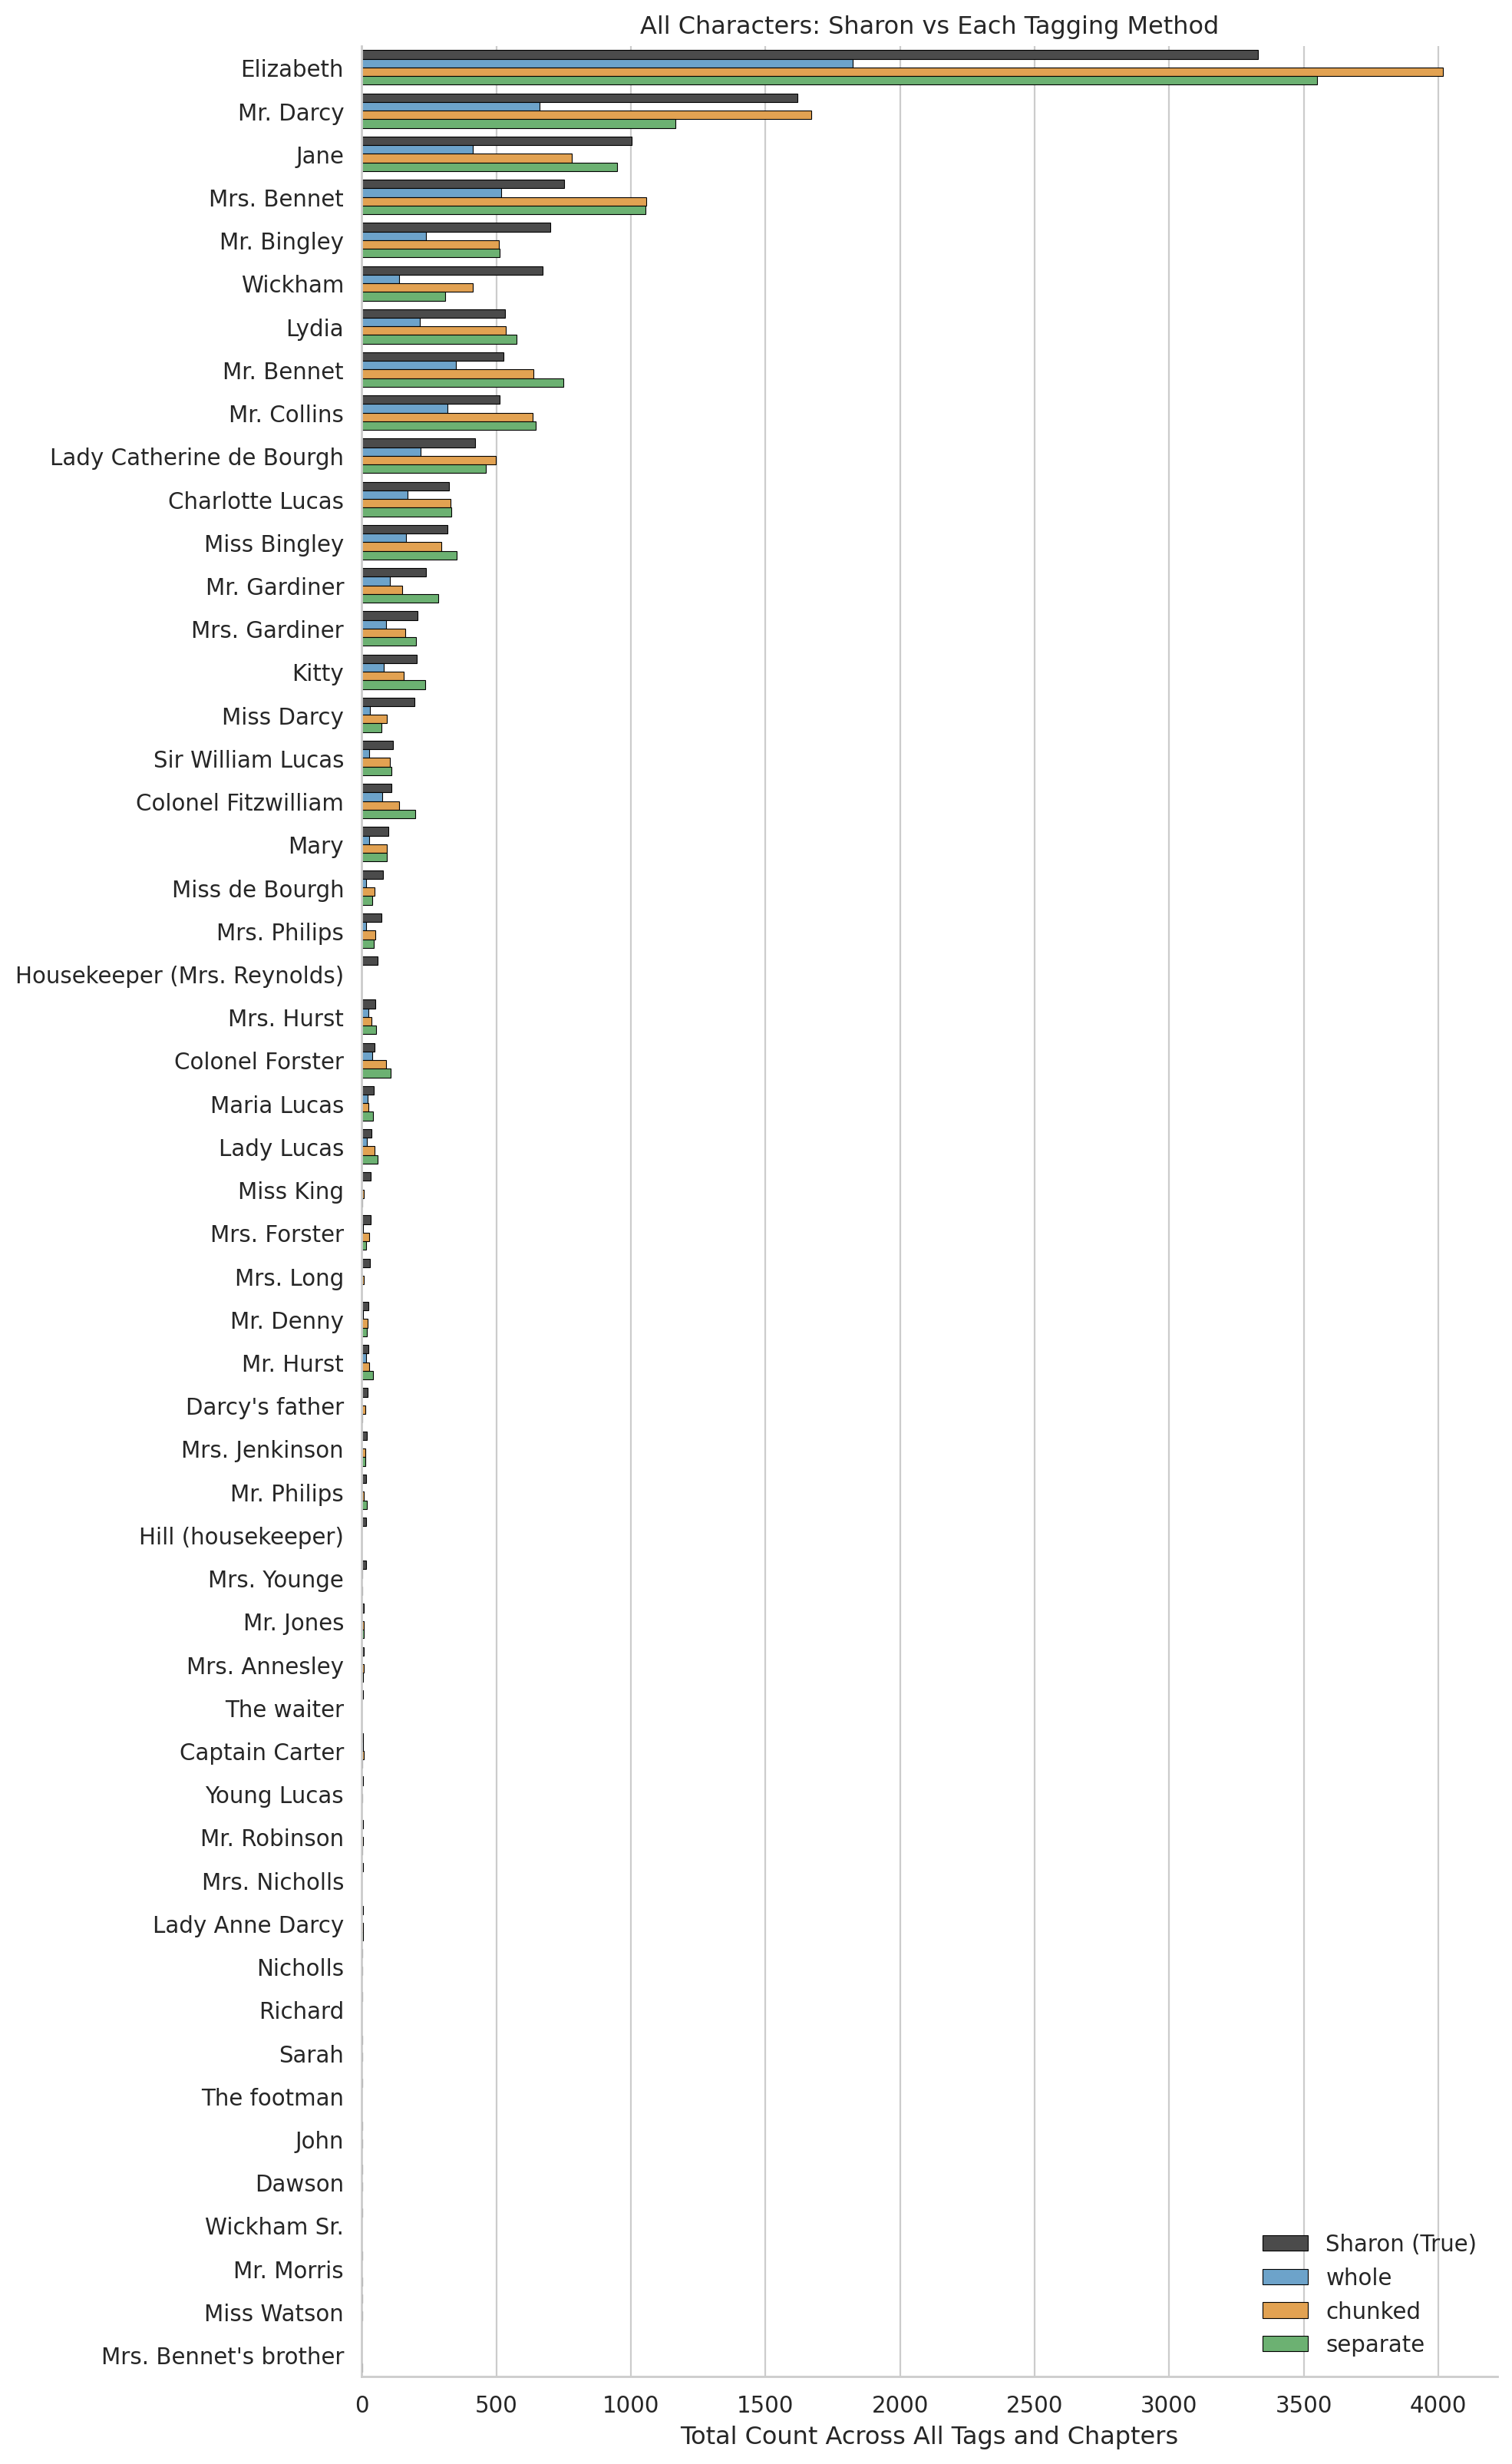

In [9]:
# --- 1) Prepare combined dataframe ---
model_totals = (
    merged_filtered
    .groupby(["character", "method"], as_index=False)["count"]
    .sum()
)

# Deduplicate Sharon (remove triple count)
sharon_totals = (
    merged_filtered
    .groupby(["chapter", "character", "tag"], as_index=False)["true_count"]
    .max()
    .groupby(["character"], as_index=False)["true_count"]
    .sum()
)
sharon_totals["method"] = "Sharon (True)"
sharon_totals = sharon_totals.rename(columns={"true_count": "count"})

# Combine into one DataFrame
plot_df = pd.concat([sharon_totals, model_totals], ignore_index=True)

# --- 2) Sort characters by Sharon total descending ---
char_order = (
    sharon_totals.sort_values("count", ascending=False)["character"]
    .tolist()
)
plot_df["character"] = pd.Categorical(plot_df["character"], categories=char_order, ordered=True)

# --- 3) Define method order so Sharon appears first ---
method_order = ["Sharon (True)", "whole", "chunked", "separate"]

# --- 4) Color palette ---
palette = {
    "Sharon (True)": "#4B4B4B",
    "whole": "#5DA5DA", 
    "chunked": "#FAA43A", 
    "separate": "#60BD68",
}

# --- 5) Plot ---
plt.figure(figsize=(10, max(6, len(char_order) * 0.3)))

sns.barplot(
    data=plot_df,
    y="character", x="count", hue="method",
    order=char_order,
    hue_order=method_order,
    palette=palette,
    edgecolor="black",
    linewidth=0.4,
    dodge=True,
    errorbar=None
)

plt.title("All Characters: Sharon vs Each Tagging Method")
plt.xlabel("Total Count Across All Tags and Chapters")
plt.ylabel("")
plt.legend(frameon=False, loc="lower right", title="")
sns.despine()
plt.tight_layout()
plt.show()

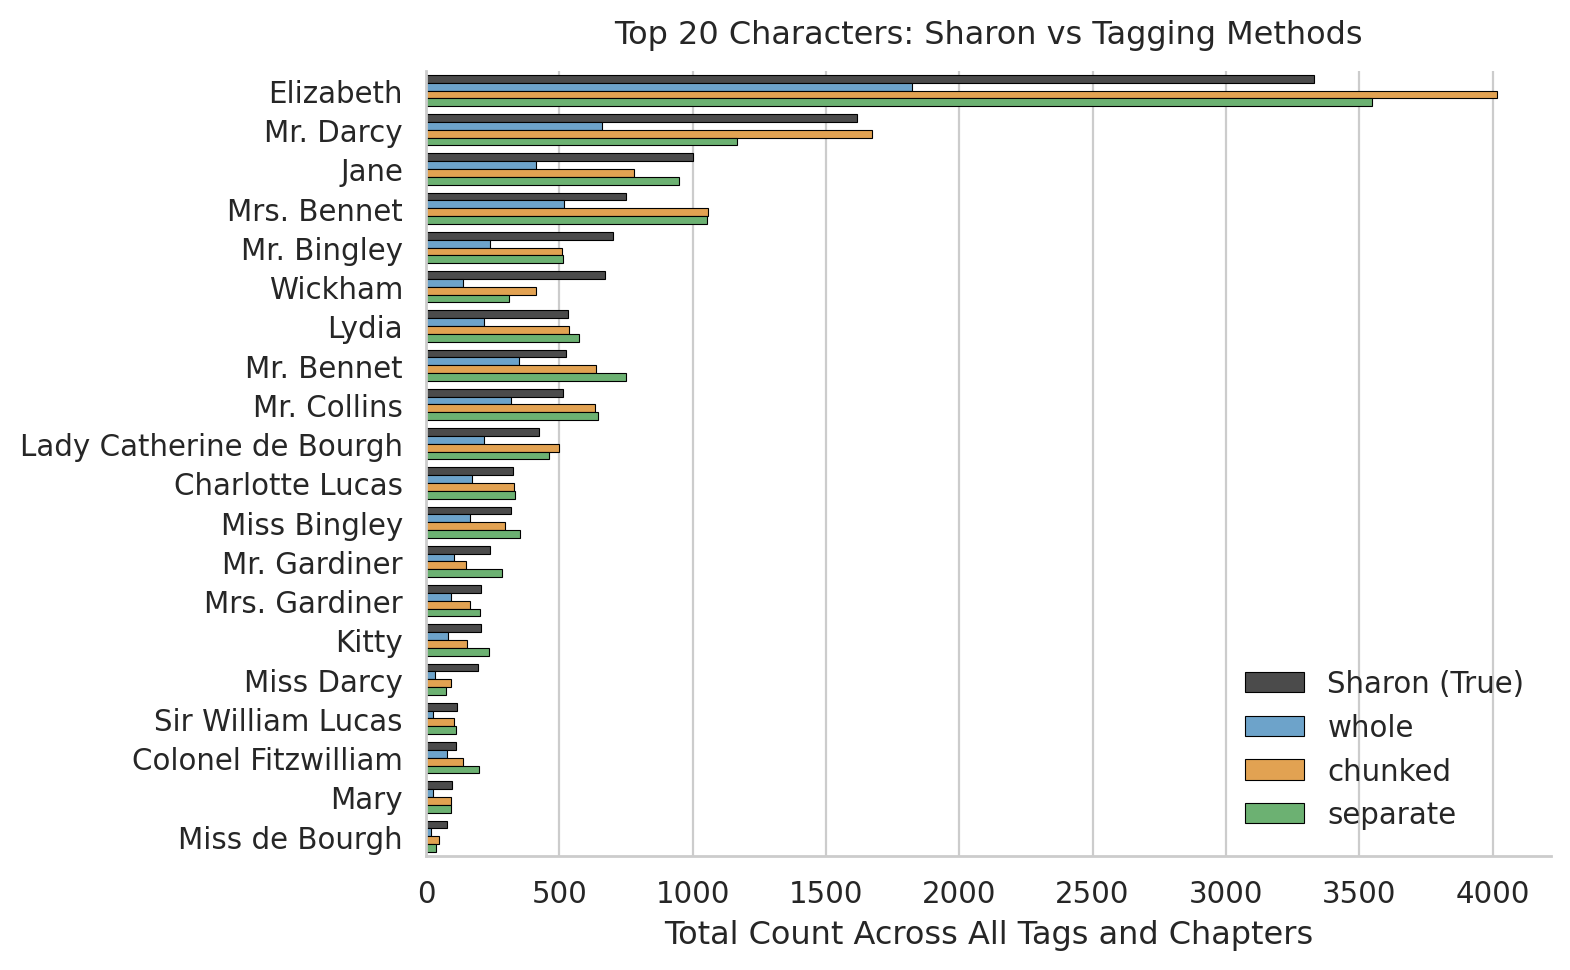

In [10]:
# Aggregate model and true counts
model_totals = (
    merged_filtered
    .groupby(["character", "method"], as_index=False)["count"]
    .sum()
)

# Deduplicate Sharon across methods (max per tag per chapter then sum)
sharon_totals = (
    merged_filtered
    .groupby(["chapter", "character", "tag"], as_index=False)["true_count"]
    .max()
    .groupby(["character"], as_index=False)["true_count"]
    .sum()
)
sharon_totals["method"] = "Sharon (True)"
sharon_totals = sharon_totals.rename(columns={"true_count": "count"})

# Combine all
plot_df = pd.concat([sharon_totals, model_totals], ignore_index=True)

# determine top 20 characters by Sharon total 
top_chars = (
    sharon_totals.sort_values("count", ascending=False)
    .head(20)["character"].tolist()
)
plot_df = plot_df[plot_df["character"].isin(top_chars)]

# Ensure correct order
plot_df["character"] = pd.Categorical(
    plot_df["character"], categories=top_chars, ordered=True
)

# Define colors and order
method_order = ["Sharon (True)", "whole", "chunked", "separate"]


# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    y="character", x="count", hue="method",
    hue_order=method_order, order=top_chars,
    palette=palette,
    edgecolor="black",
    linewidth=0.4,
    dodge=True,
    errorbar=None
)

plt.title("Top 20 Characters: Sharon vs Tagging Methods", pad=10)
plt.xlabel("Total Count Across All Tags and Chapters")
plt.ylabel("")
plt.legend(frameon=False, loc="lower right", title="")
sns.despine()
plt.tight_layout()
plt.show()

In [11]:
# Basic per-method metrics 
mf = merged_filtered.assign(
    error=lambda d: d["count"] - d["true_count"],
    abs_error=lambda d: (d["count"] - d["true_count"]).abs()
)

stats = (
    mf.groupby("method", as_index=False)
      .agg(
          total_pred=("count", "sum"),
          total_true=("true_count", "sum"),
          mae=("abs_error", "mean"),   # mean absolute error per row
          rmse=("error", lambda x: np.sqrt(np.mean(np.square(x)))),  # root mean square error
          corr=("count", lambda x: np.corrcoef(x, mf.loc[x.index, "true_count"])[0, 1] 
                if len(x) > 1 else np.nan)
      )
)

# Bias direction
stats["bias"] = (stats["total_pred"] - stats["total_true"]) / stats["total_true"].replace(0, np.nan)

# accuracy summary
stats["total_abs_error"] = abs(stats["total_pred"] - stats["total_true"])
stats["accuracy"] = 1 - (stats["total_abs_error"] / stats["total_true"].replace(0, np.nan))

# Display
print(stats[["method", "total_pred", "total_true", "bias", "mae", "rmse", "corr", "accuracy"]].round(3))

     method  total_pred  total_true   bias    mae   rmse   corr  accuracy
0   chunked       12752       12576  0.014  2.690  5.897  0.258     0.986
1  separate       12353       12576 -0.018  2.654  5.373  0.251     0.982
2     whole        5845       12576 -0.535  2.089  4.942  0.257     0.465


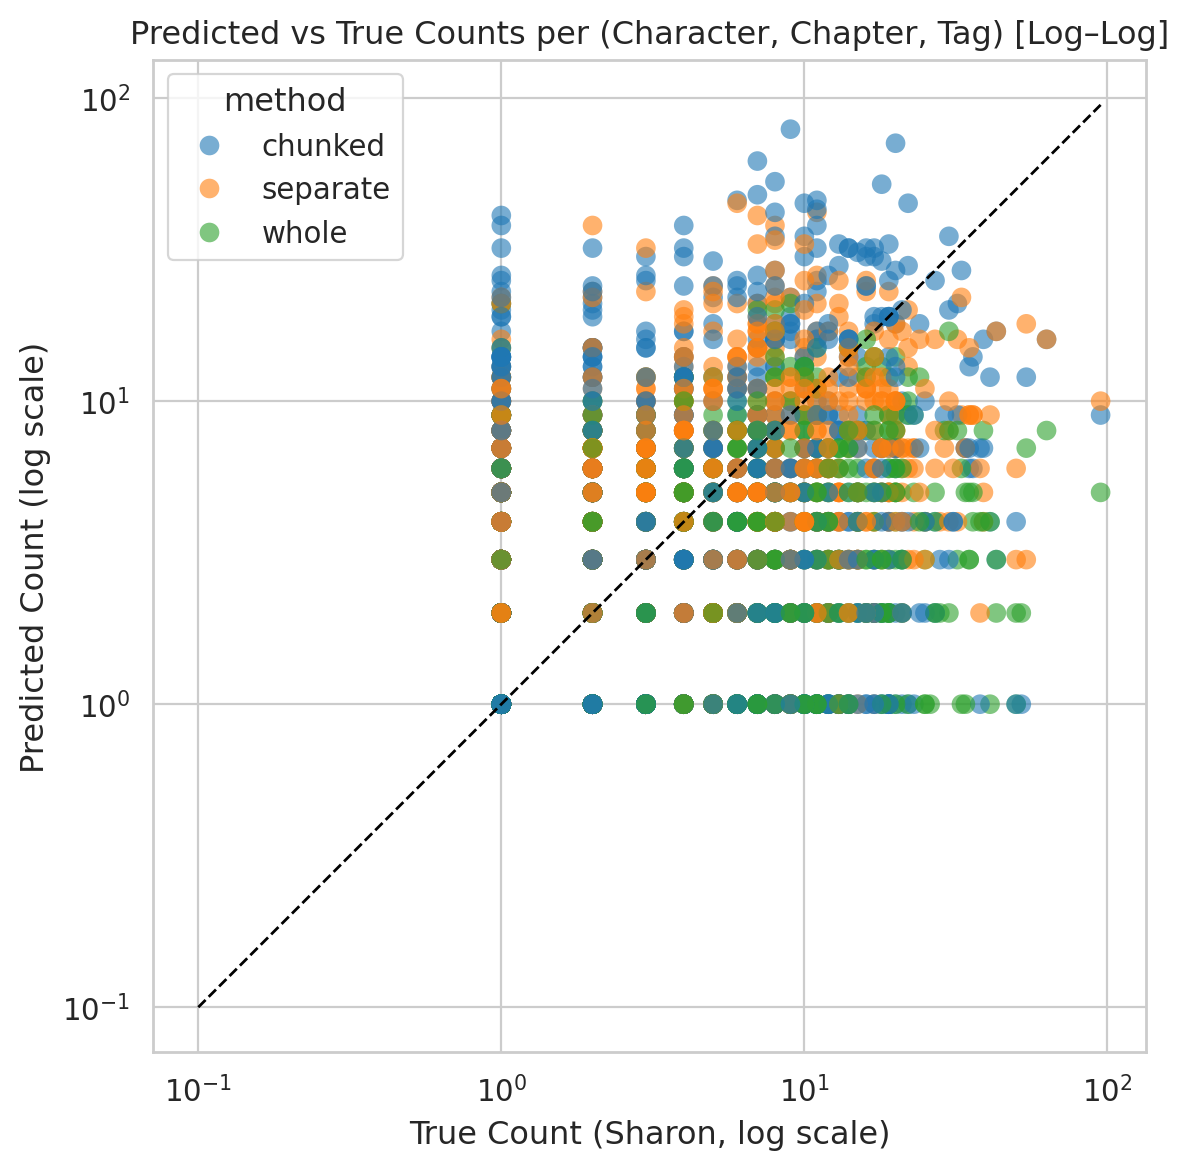

In [12]:
plt.figure(figsize=(8, 6))

# Scatter points
sns.scatterplot(
    data=merged_filtered,
    x="true_count", y="count",
    hue="method", alpha=0.6, s=50, edgecolor="none"
)
# Axes scaling
plt.xscale("log")
plt.yscale("log")

# Diagonal reference line (y = x)
max_val = max(merged_filtered["true_count"].max(), merged_filtered["count"].max())
min_val = 1e-1  # avoid log(0)
plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=1)

# plotting
plt.xlabel("True Count (Sharon, log scale)")
plt.ylabel("Predicted Count (log scale)")
plt.title("Predicted vs True Counts per (Character, Chapter, Tag) [Log–Log]")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

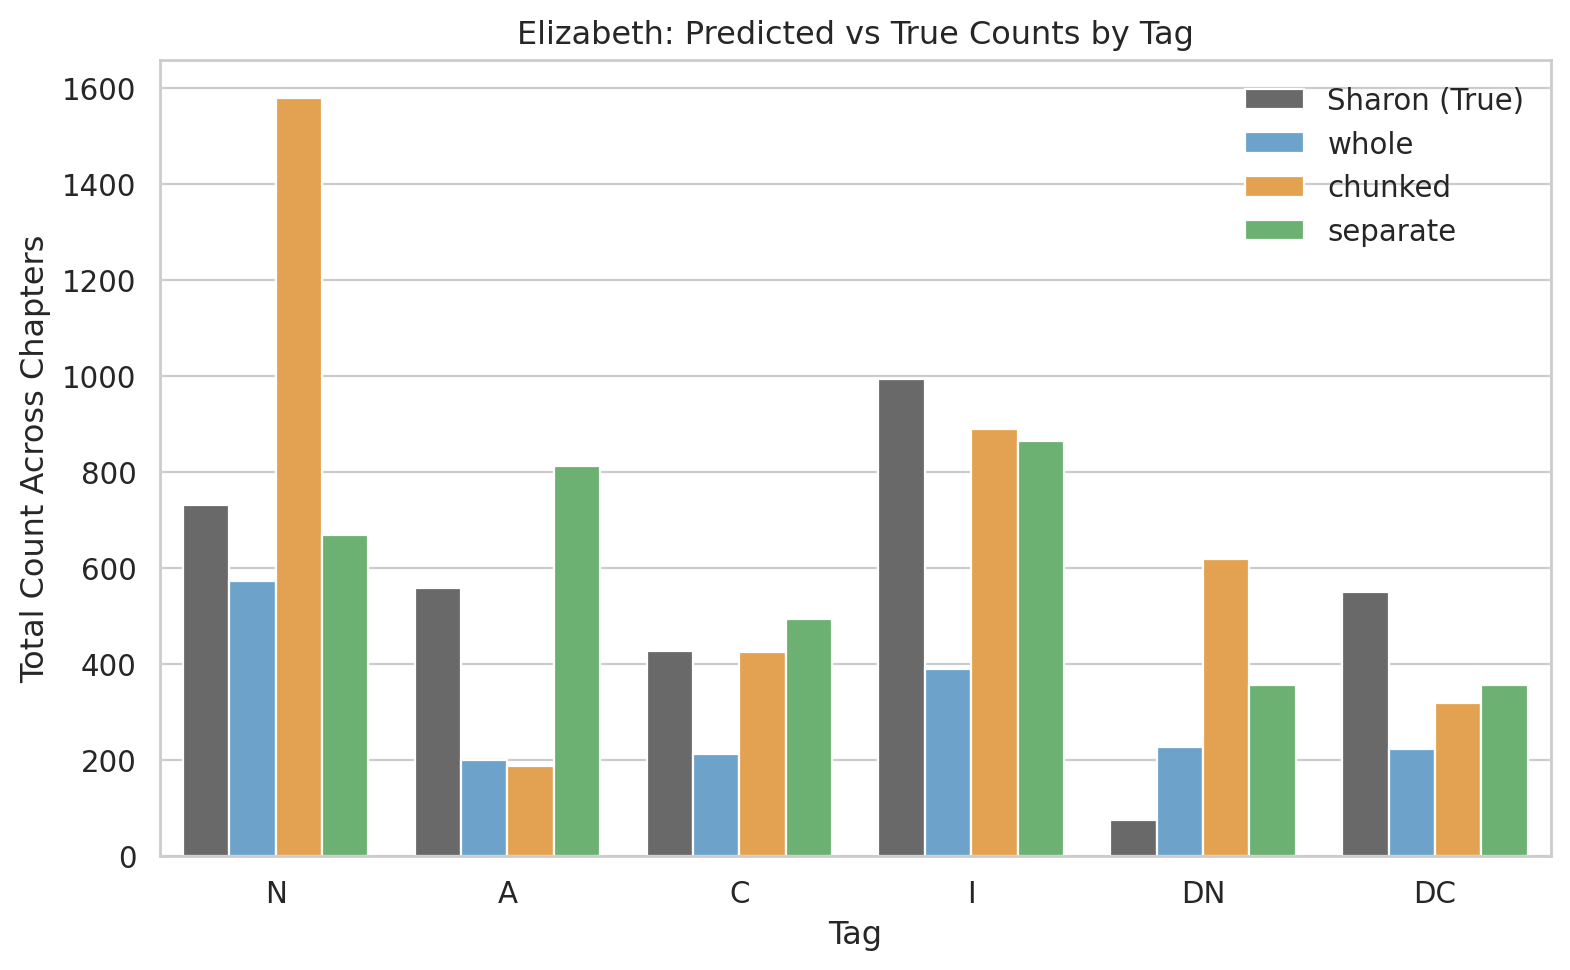

In [13]:
def plot_character_breakdown(char_name):
    """Plot true vs. predicted tag counts for one character, with Sharon's bar first."""

    # --- model predictions (summed across all chapters)
    pred = (
        merged_filtered[merged_filtered["character"].str.contains(char_name, case=False)]
        .groupby(["tag", "method"], as_index=False)["count"].sum()
    )

    # --- Sharon truth (directly from original data)
    true = (
        sharon_long[sharon_long["character"].str.contains(char_name, case=False)]
        .groupby("tag", as_index=False)["true_count"].sum()
    )

    # --- consistent tag order
    tag_order = ["N", "A", "C", "I", "DN", "DC"]
    for df in [pred, true]:
        df["tag"] = pd.Categorical(df["tag"], categories=tag_order, ordered=True)

    # --- merge true + predicted (Sharon first)
    true["method"] = "Sharon (True)"
    true = true.rename(columns={"true_count": "count"})
    plot_df = pd.concat([true, pred], ignore_index=True)

    # --- palette
    palette = {
        "Sharon (True)": "dimgray",
        "whole": "#5DA5DA",
        "chunked": "#FAA43A",
        "separate": "#60BD68"
    }

    # --- plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=plot_df,
        x="tag", y="count", hue="method",
        hue_order=["Sharon (True)", "whole", "chunked", "separate"],
        palette=palette, errorbar=None
    )
    plt.title(f"{char_name}: Predicted vs True Counts by Tag")
    plt.ylabel("Total Count Across Chapters")
    plt.xlabel("Tag")
    plt.legend(title="", frameon=False)
    plt.tight_layout()
    plt.show()

plot_character_breakdown("Elizabeth")

In [18]:
def plot_tag_specific(tag="N", top_n=20):
    # Compute totals for the chosen tag and keep only top_n
    df_tag = (
        sharon_long[sharon_long["tag"] == tag]
        .groupby("character", as_index=False)["true_count"].sum()
        .sort_values("true_count", ascending=False)
        .head(top_n)
    )

    # Maintain top_n order
    order = df_tag["character"].tolist()
    df_tag["character"] = pd.Categorical(df_tag["character"], categories=order, ordered=True)

    # Adjust figure height dynamically
    h = max(5.5, 0.4 * len(df_tag))
    plt.figure(figsize=(8, h))

    tag_colors = {
    "N": "#F58EA8",  # pink
    "A": "#7EB0D5",  # blue
    "C": "#E76F51",  # red
    "I": "#F9D57E",  # yellow
    "DN": "#C97BF2", # purple
    "DC": "#FF9E6B"  # orange
    }
    color = tag_colors.get(tag, "#CCCCCC")
    ax = sns.barplot(
        data=df_tag,
        y="character", x="true_count",
        order=order,
        color=color,
        edgecolor="black", linewidth=0.3
    )

    # Clean, readable style
    ax.set_title(f"Top {top_n} '{tag}' Tag Weights in Pride and Prejudice", pad=10)
    ax.set_xlabel("Weight")
    ax.set_ylabel("")
    ax.grid(True, axis="x", linestyle=":", linewidth=0.6)
    ax.grid(False, axis="y")
    ax.tick_params(axis="y", labelsize=10)
    sns.despine()
    plt.tight_layout()
    plt.show()
    
def plot_characters_per_chapter_comparison():
    """
    Compare # of characters identified per chapter:
    Sharon (true) vs each model method.
    """

    # --- Sharon true counts ---
    sharon_nonzero = sharon_long[sharon_long["true_count"] > 0]
    sharon_counts = (
        sharon_nonzero.groupby("chapter")["character"].nunique().reset_index()
        .rename(columns={"character": "num_characters"})
    )
    sharon_counts["method"] = "Sharon (True)"

    # --- Model counts ---
    model_nonzero = merged_filtered[merged_filtered["count"] > 0]
    model_counts = (
        model_nonzero.groupby(["method", "chapter"])["character"].nunique().reset_index()
        .rename(columns={"character": "num_characters"})
    )

    # --- Combine ---
    combined = pd.concat([sharon_counts, model_counts], ignore_index=True)

    # --- Plot ---
    plt.figure(figsize=(12, 4))
    ax = sns.barplot(
        data=combined,
        x="chapter",
        y="num_characters",
        hue="method",
        palette={
            "Sharon (True)": "black",
            "whole": "#5DA5DA",
            "chunked": "#FAA43A",
            "separate": "#60BD68",
        },
        edgecolor="black",
        linewidth=0.3,
        dodge=True,
        errorbar=None
    )

    # --- Titles and labels ---
    ax.set_title("Number of Characters Identified per Chapter", pad=10)
    ax.set_xlabel("Chapter")
    ax.set_ylabel("Number of Characters with Nonzero Tags")

    # --- Only show every 5th tick ---
    chapters = sorted(combined["chapter"].unique())
    step = max(1, len(chapters) // 12)  # adaptive scaling
    show_ticks = chapters[::5] if len(chapters) > 5 else chapters
    ax.set_xticks(show_ticks)
    ax.set_xticklabels(show_ticks)

    # --- Legend clean and outside ---
    ax.legend(
        title="",
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    # --- Style ---
    ax.grid(True, axis="y", linestyle=":", linewidth=0.6)
    ax.grid(False, axis="x")
    sns.despine()
    plt.tight_layout()
    plt.show()
    
def plot_character_components_model(character="Elizabeth Bennet", method="chunked"):
    """
    Plot per-chapter component weights for a given character,
    using model-predicted counts (for a specified method).
    """

    df_char_model = (
        merged_filtered[
            (merged_filtered["method"] == method)
            & (merged_filtered["character"].str.contains(character, case=False))
        ]
        .groupby(["chapter", "tag"], as_index=False)["count"].sum()
        .pivot(index="chapter", columns="tag", values="count")
        .fillna(0)
    )

    if df_char_model.empty:
        print(f"No data found for {character} in method '{method}'.")
        return

    df_char_model.plot(
        kind="bar", stacked=True, figsize=(11, 5),
        color=sns.color_palette("husl", n_colors=df_char_model.shape[1])
    )
    plt.title(f"Model Components for {character} by Chapter ({method})")
    plt.xlabel("Chapter")
    plt.ylabel("Predicted Weight")
    plt.legend(title="Tag", bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine()
    plt.tight_layout()
    plt.show()

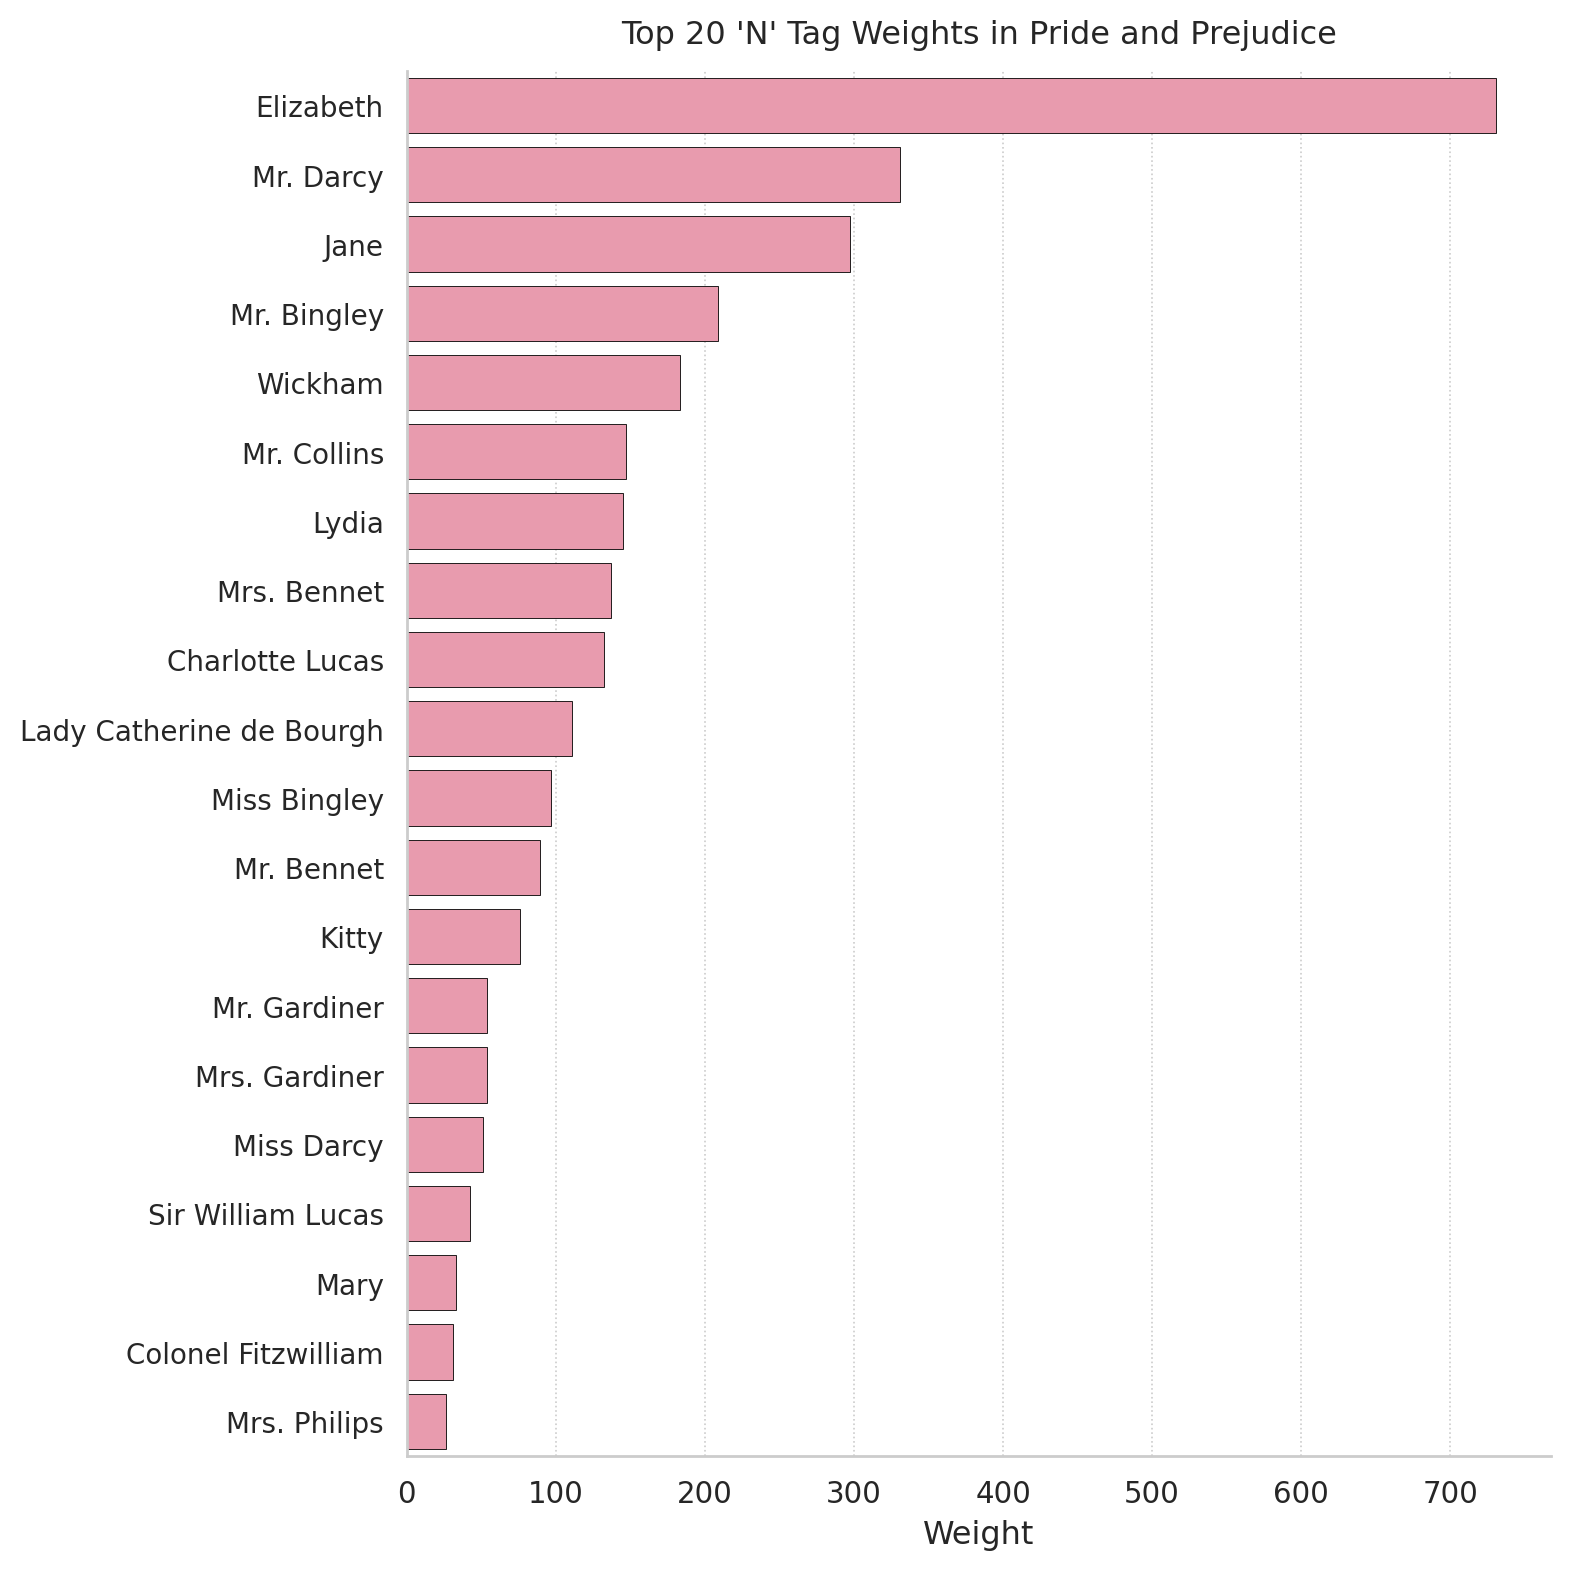

In [19]:
plot_tag_specific(tag="N", top_n=20)

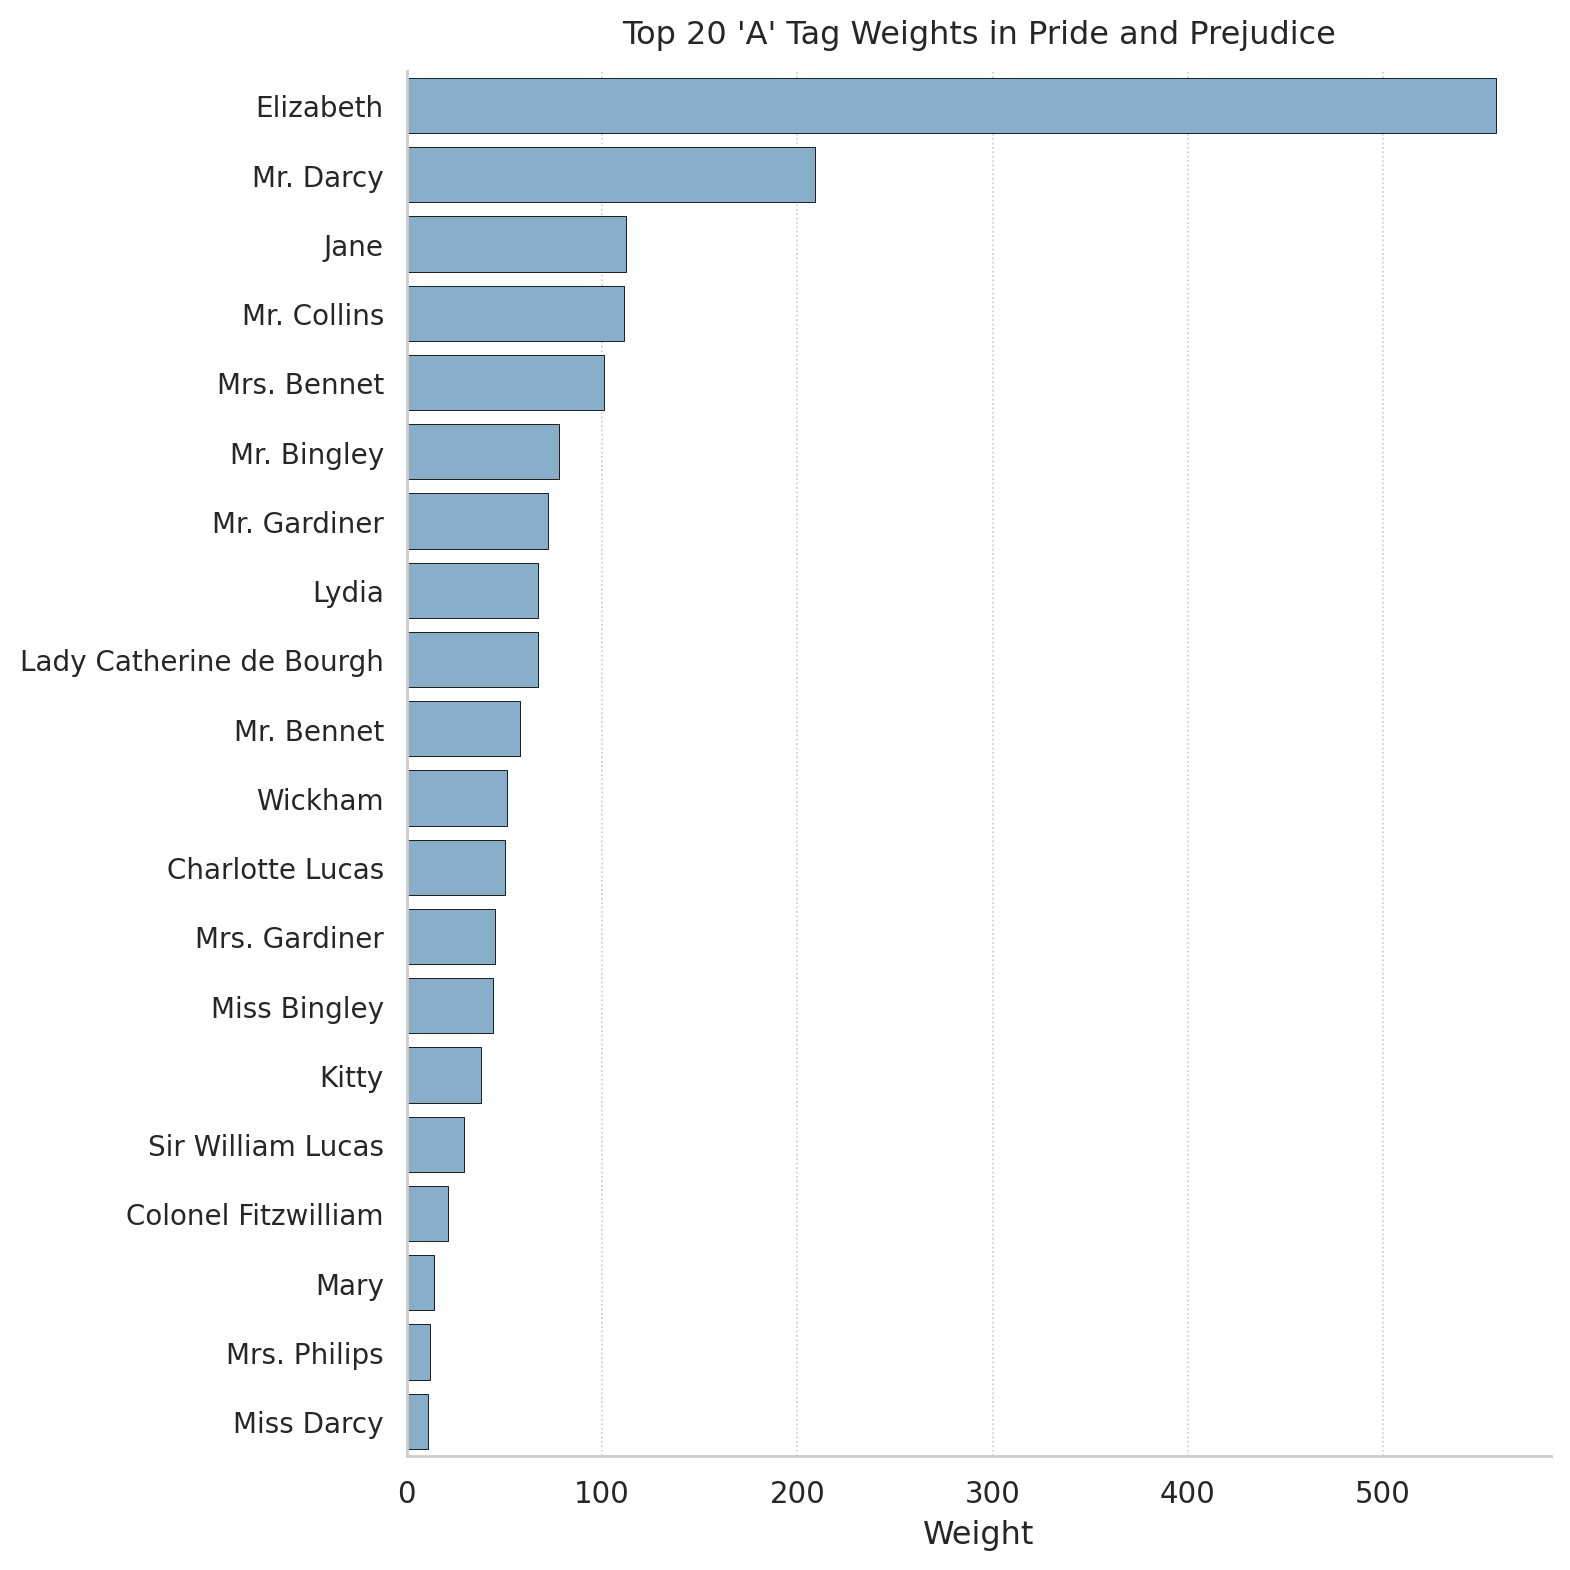

In [21]:
plot_tag_specific(tag="A", top_n=20)

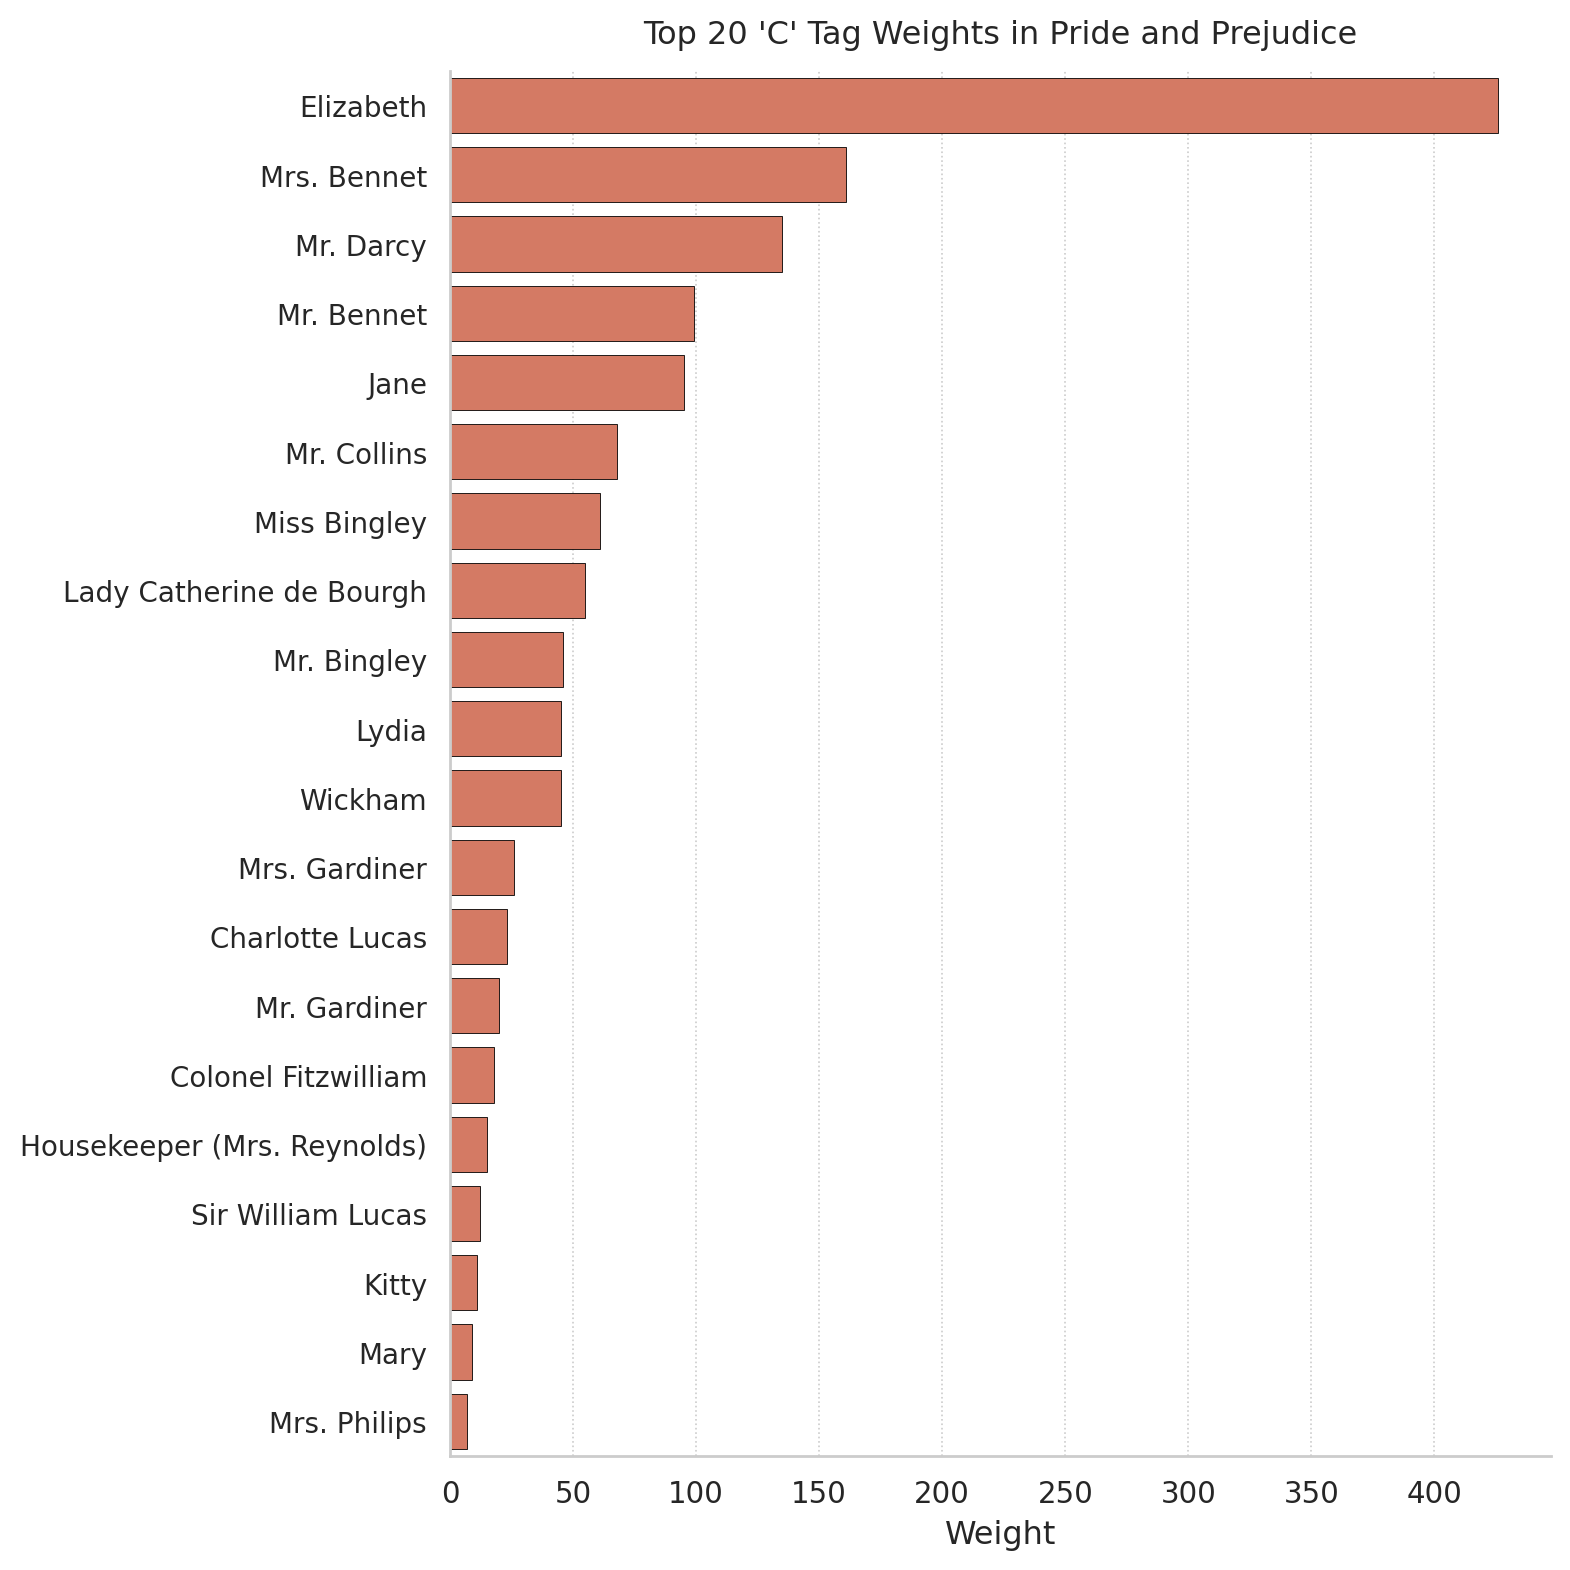

In [20]:
plot_tag_specific(tag="C", top_n=20)

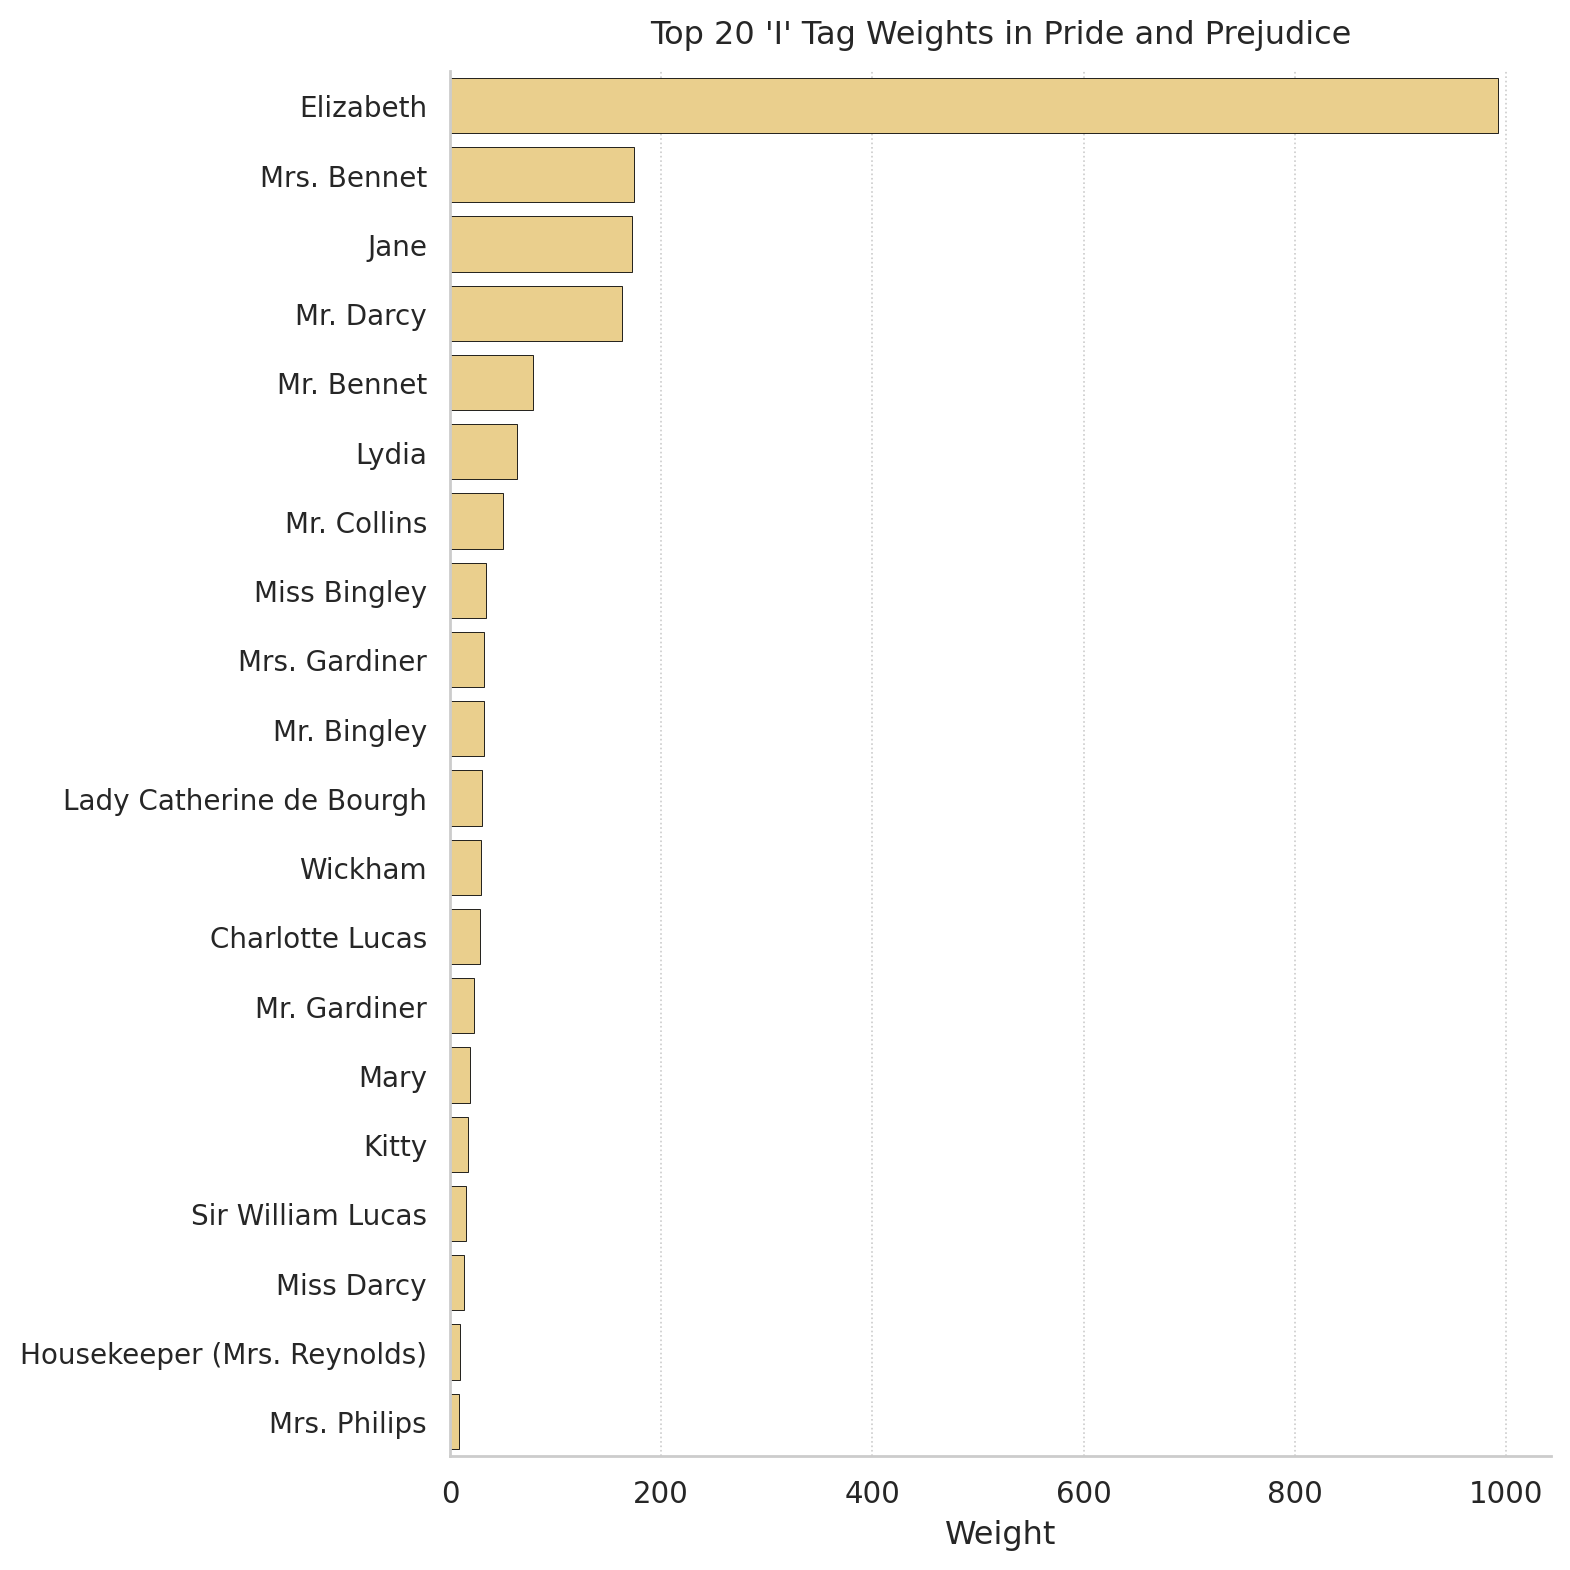

In [22]:
plot_tag_specific(tag="I", top_n=20)

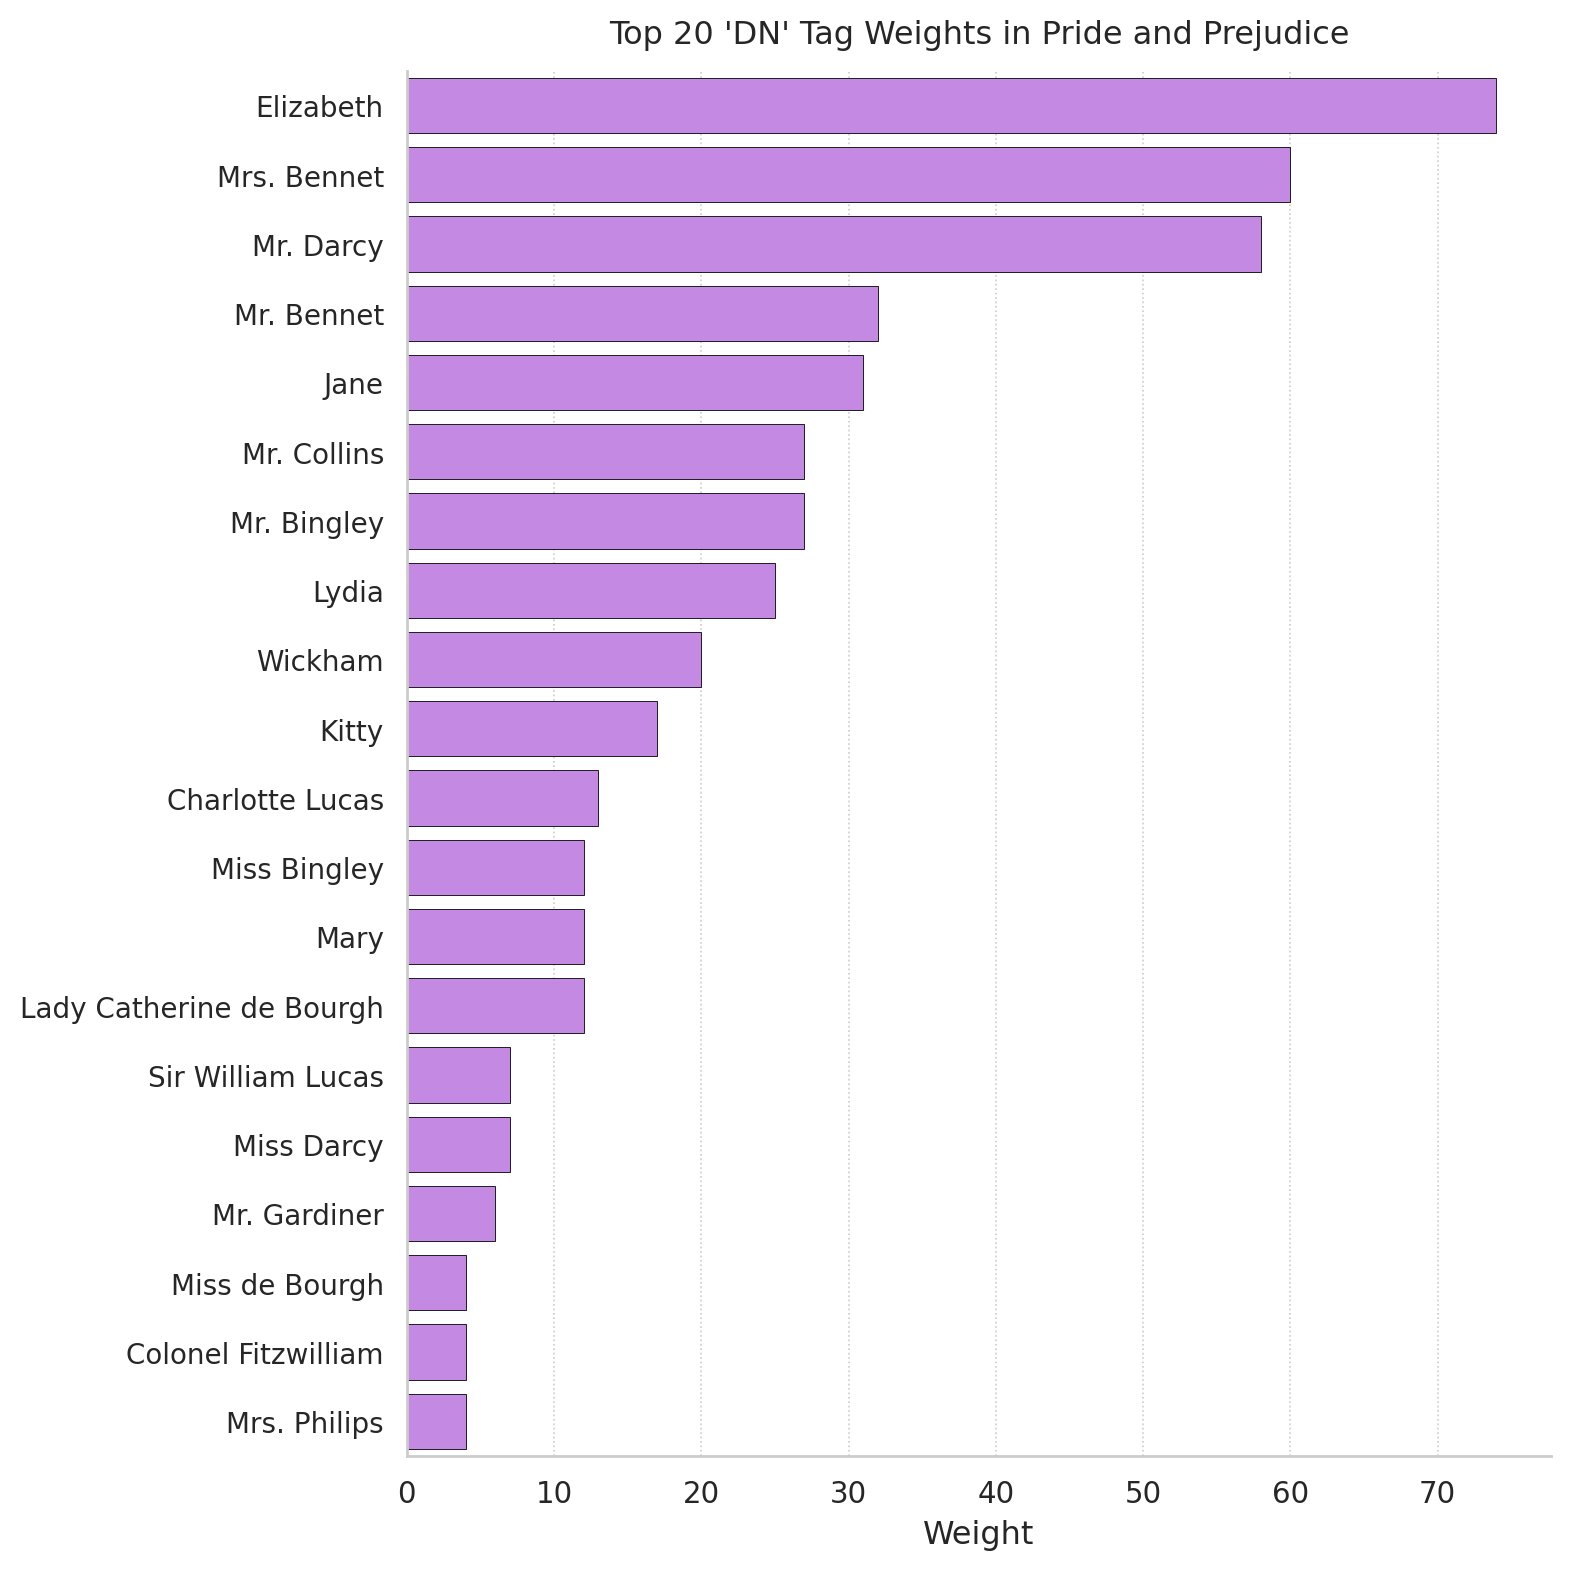

In [23]:
plot_tag_specific(tag="DN", top_n=20)

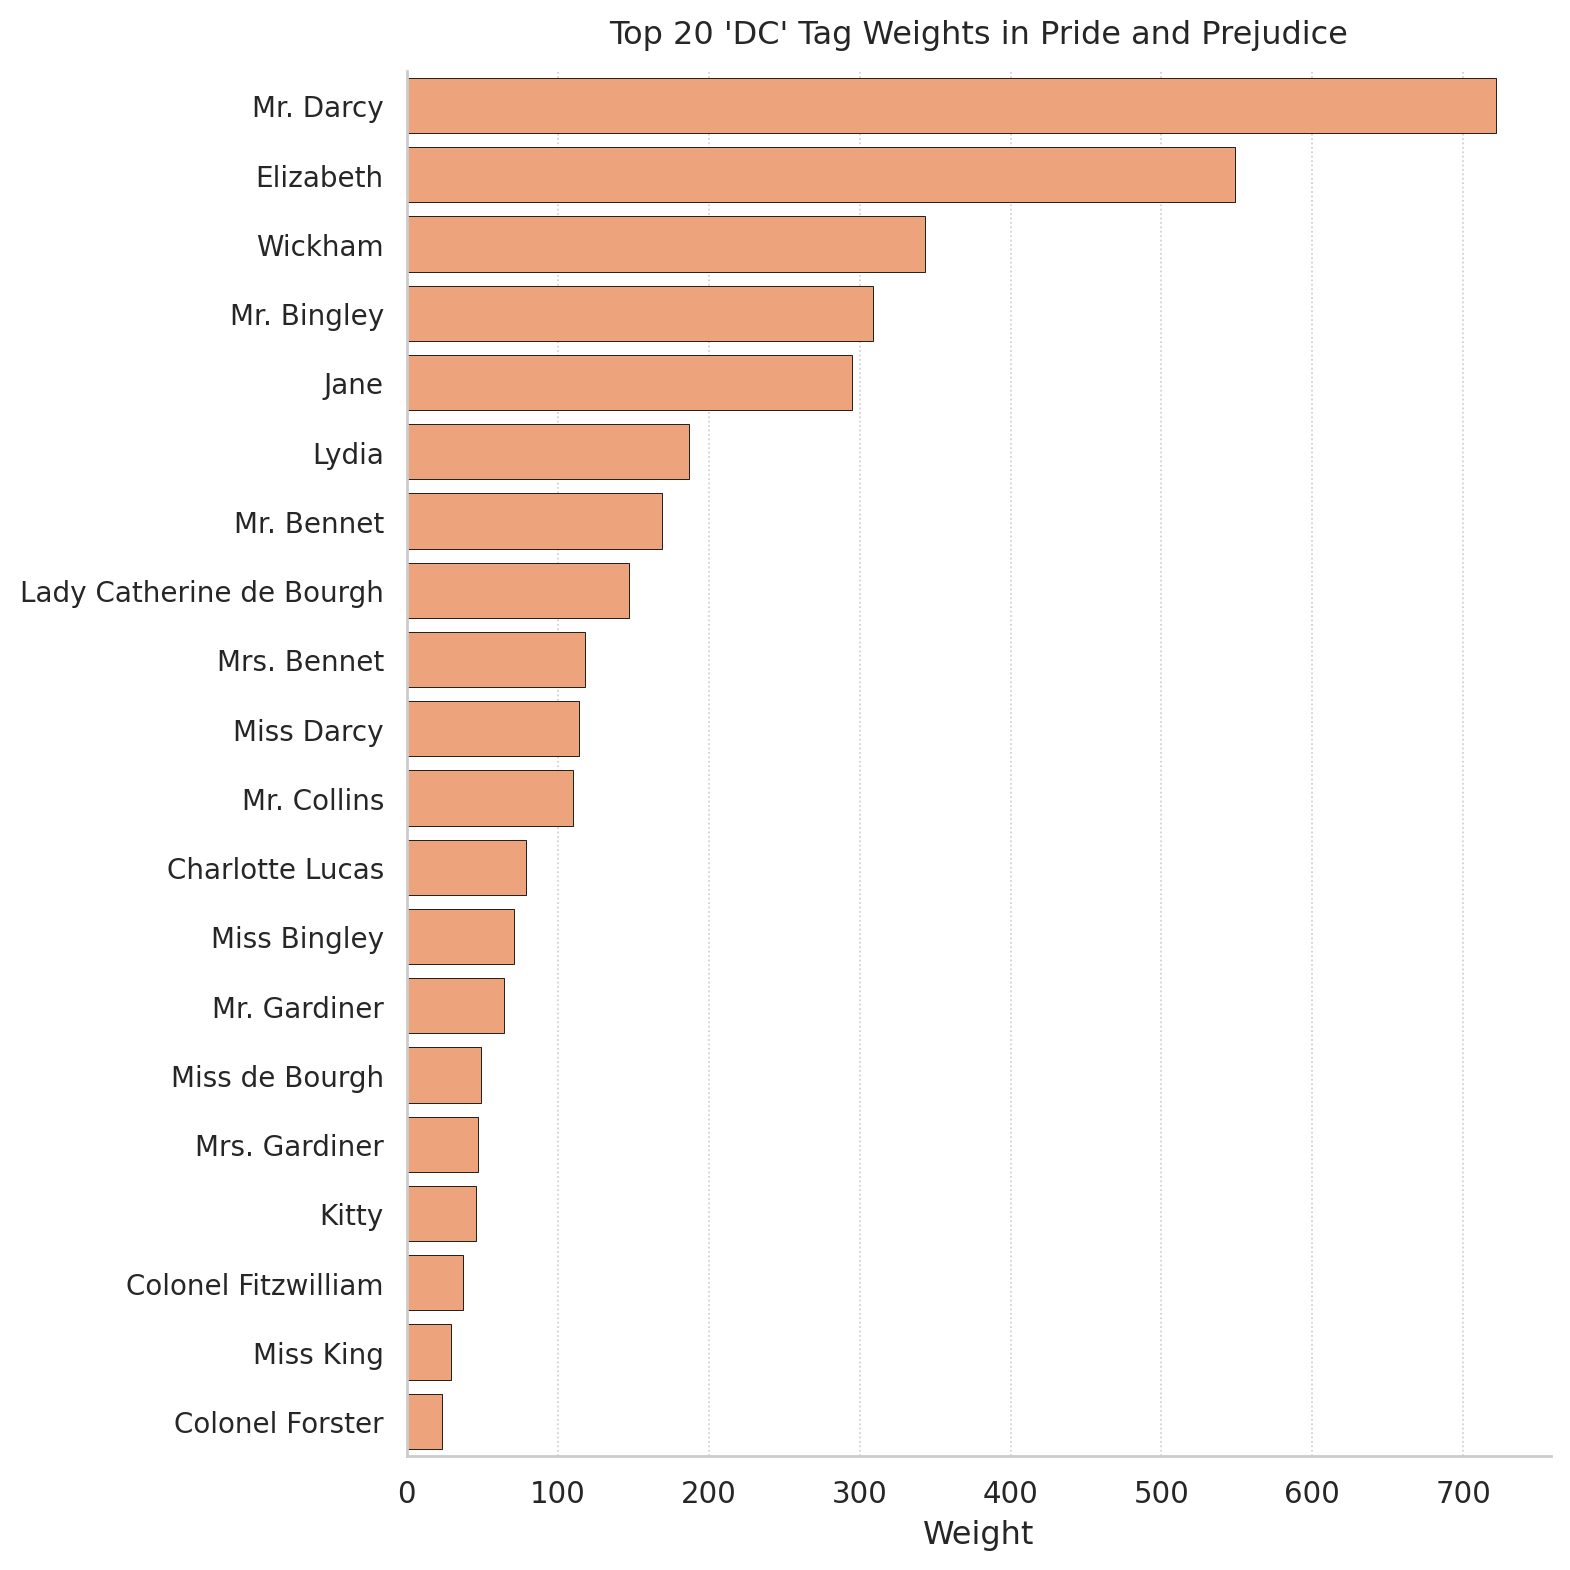

In [24]:
plot_tag_specific(tag="DC", top_n=20)